In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [34]:
df = pd.read_csv("Loan_default.csv")

df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [35]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [36]:
df = df.drop(columns=['LoanID'])

In [37]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64


In [38]:
df.fillna(0, inplace=True)

In [39]:
print("Duplicate rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicate rows after removal:", df.duplicated().sum())

Duplicate rows: 0
Duplicate rows after removal: 0


In [40]:
categorical_cols = ['Education','EmploymentType','MaritalStatus',
                    'HasMortgage','HasDependents','LoanPurpose','HasCoSigner']

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [41]:
print(df.describe())

                 Age         Income     LoanAmount    CreditScore  \
count  255347.000000  255347.000000  255347.000000  255347.000000   
mean       43.498306   82499.304597  127578.865512     574.264346   
std        14.990258   38963.013729   70840.706142     158.903867   
min        18.000000   15000.000000    5000.000000     300.000000   
25%        31.000000   48825.500000   66156.000000     437.000000   
50%        43.000000   82466.000000  127556.000000     574.000000   
75%        56.000000  116219.000000  188985.000000     712.000000   
max        69.000000  149999.000000  249999.000000     849.000000   

       MonthsEmployed  NumCreditLines   InterestRate       LoanTerm  \
count   255347.000000   255347.000000  255347.000000  255347.000000   
mean        59.541976        2.501036      13.492773      36.025894   
std         34.643376        1.117018       6.636443      16.969330   
min          0.000000        1.000000       2.000000      12.000000   
25%         30.000000  

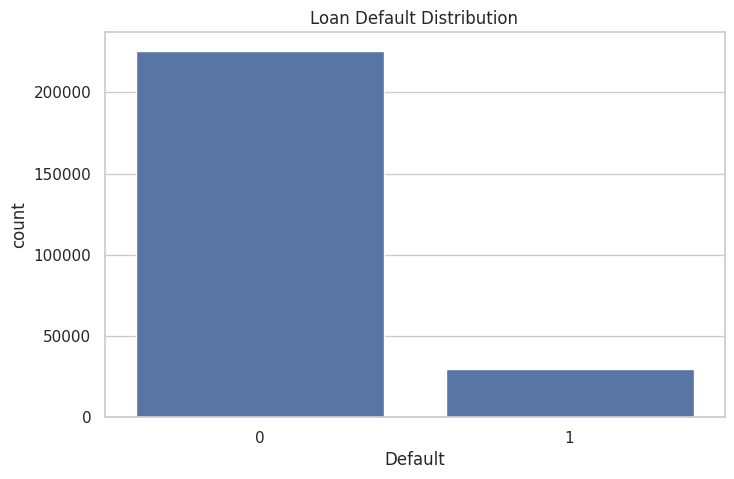

In [42]:
plt.figure(figsize=(8,5))
sns.countplot(x='Default', data=df)
plt.title("Loan Default Distribution")
plt.show()

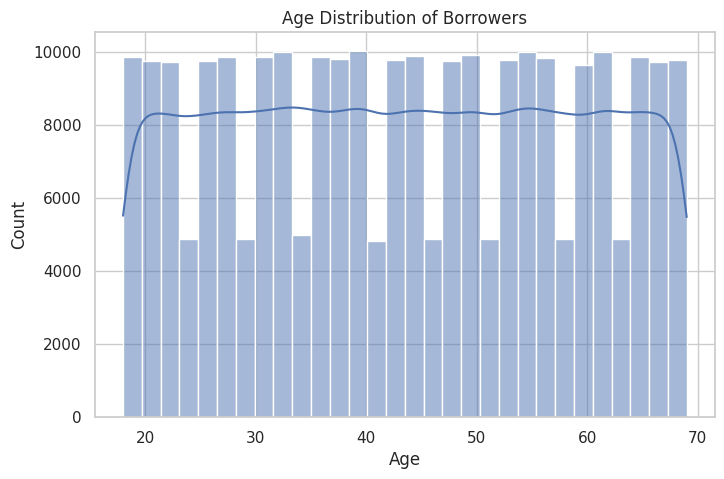

In [43]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution of Borrowers")
plt.show()

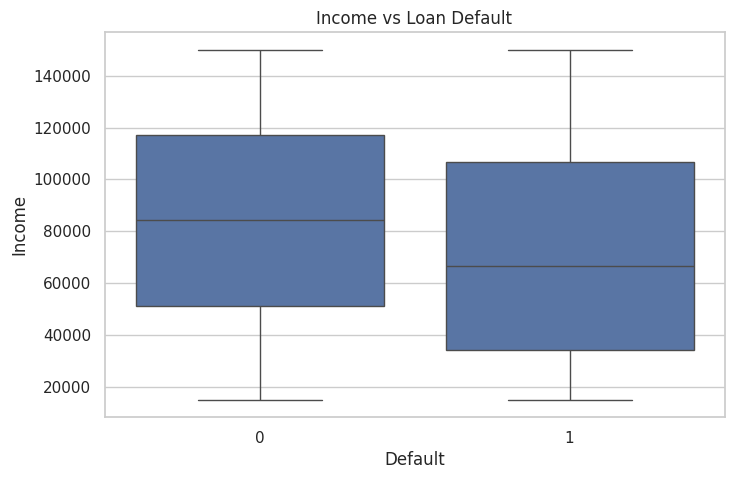

In [44]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Default', y='Income', data=df)
plt.title("Income vs Loan Default")
plt.show()

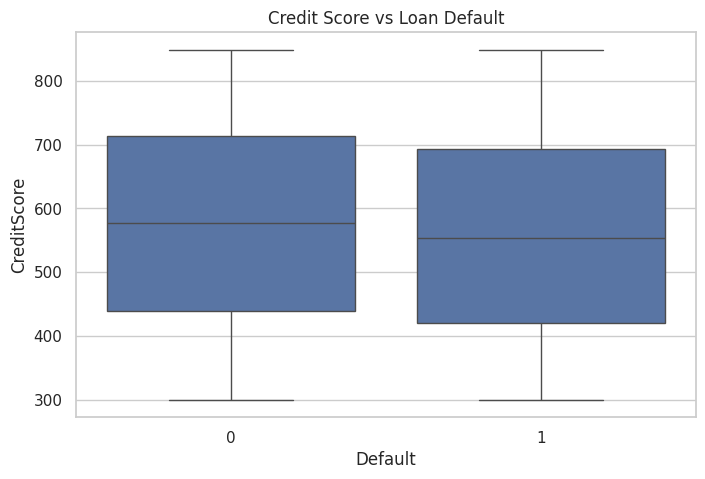

In [45]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Default', y='CreditScore', data=df)
plt.title("Credit Score vs Loan Default")
plt.show()

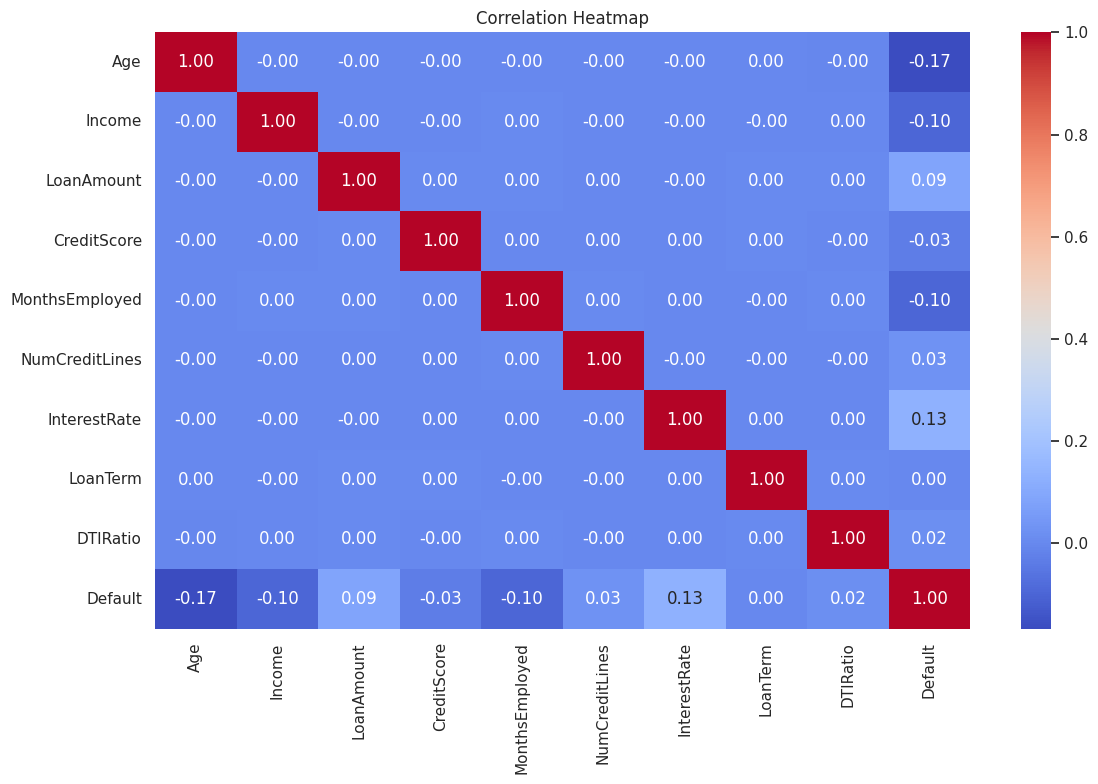

In [56]:
# 6. Correlation heatmap
corr_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
             'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Default']
plt.figure(figsize=(12, 8))
sns.heatmap(cleaned_df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


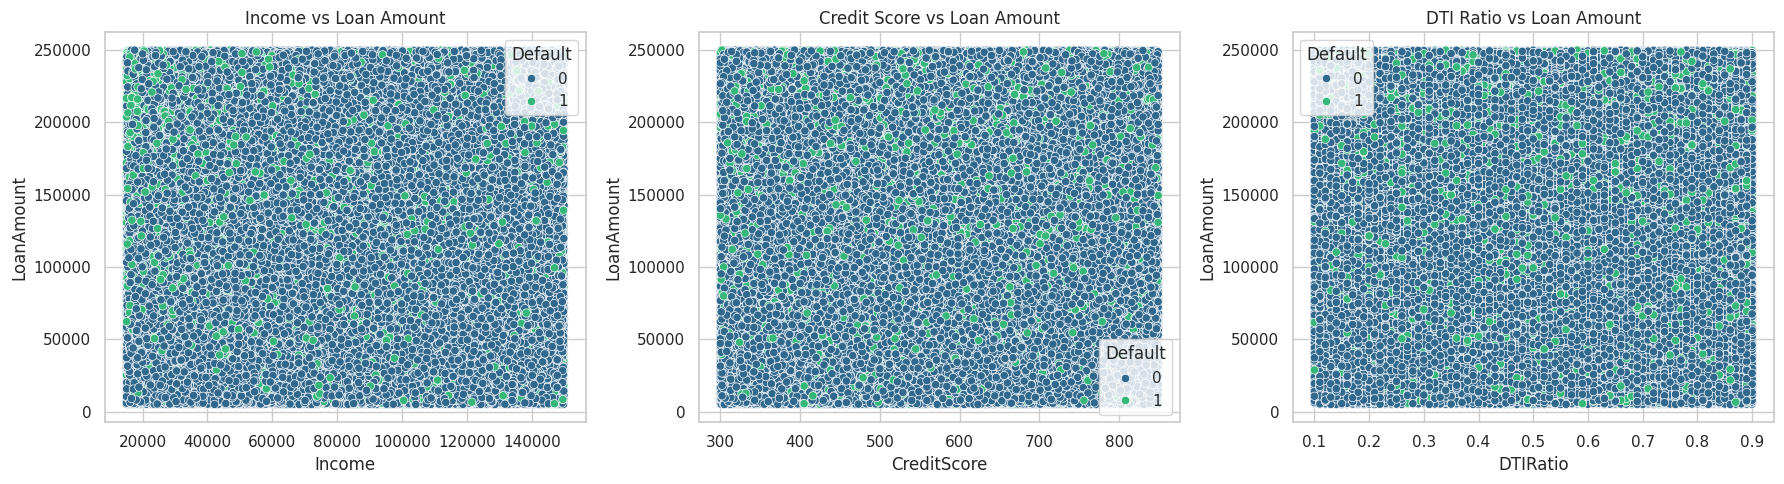

In [48]:
plt.figure(figsize=(18,5))

# Plot 1
plt.subplot(1,3,1)
sns.scatterplot(x='Income', y='LoanAmount', data=df, hue='Default', palette='viridis')
plt.title("Income vs Loan Amount")

# Plot 2
plt.subplot(1,3,2)
sns.scatterplot(x='CreditScore', y='LoanAmount', data=df, hue='Default', palette='viridis')
plt.title("Credit Score vs Loan Amount")

# Plot 3
plt.subplot(1,3,3)
sns.scatterplot(x='DTIRatio', y='LoanAmount', data=df, hue='Default', palette='viridis')
plt.title("DTI Ratio vs Loan Amount")

plt.tight_layout()
plt.show()

In [72]:
# Select features and target
X = cleaned_df[['Age','Income','LoanAmount','CreditScore',
                'NumCreditLines','InterestRate','MonthsEmployed',
                'LoanTerm','DTIRatio']]

y = cleaned_df['Default']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=88
)

In [64]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=88)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("\nLogistic Regression Performance:")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))


Logistic Regression Performance:
Accuracy: 0.8836107303700803
Precision: 0.5400943396226415
Recall: 0.02558659217877095
F1 Score: 0.04885854491145722


In [65]:
# Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=88)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("\nDecision Tree Classifier Performance:")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall:", recall_score(y_test, dt_pred))
print("F1 Score:", f1_score(y_test, dt_pred))


Decision Tree Classifier Performance:
Accuracy: 0.8007962926701913
Precision: 0.19020031421838177
Recall: 0.2164245810055866
F1 Score: 0.20246681300303127


In [66]:
# Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=88)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("\nRandom Forest Classifier Performance:")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))


Random Forest Classifier Performance:
Accuracy: 0.8836237843482802
Precision: 0.5201845444059977
Recall: 0.050391061452513965
F1 Score: 0.09188143017215035


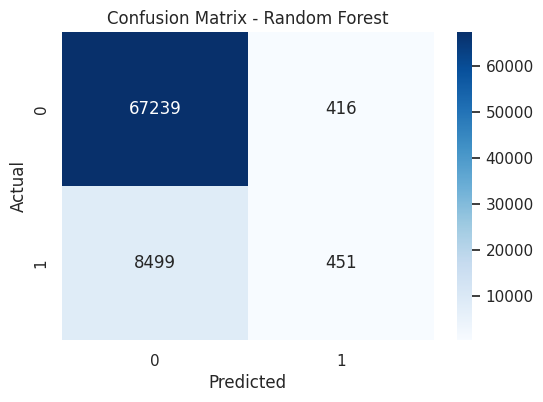

In [68]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()